# Notebook: Clasificación HAM10000 con CoAtNet-0

## 1: Instalación de dependencias

In [1]:
# Instalación definitiva y limpieza de conflictos
%pip install -q \
    "tensorflow[and-cuda]==2.16.1" \
    tf-keras==2.16.0 \
    keras-cv==0.9.0 \
    keras-cv-attention-models \
    pandas matplotlib scikit-learn ipywidgets seaborn \
    lime shap opencv-python \
    python-dotenv kaggle \
    optuna optuna-dashboard optuna-integration \
    pydot \
    weave


# Borramos Keras 3 justo después por si TensorFlow lo ha vuelto a instalar
# %pip uninstall -y keras keras-core

# Hay que instalar manualmente graphviz
# sudo apt install graphviz

# Después tendrás que reiniciar el kernel

Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install -q --upgrade wandb

Note: you may need to restart the kernel to use updated packages.


In [3]:
# Cargamos las variables de entorno del archivo .env
import os
from dotenv import load_dotenv

# Carga las variables del archivo .env al entorno del sistema
load_dotenv()

True

## 2: Configuración de la GPU y librerías

In [4]:
import os

# 1. Forzamos modo Legacy para CoAtNet
os.environ["TF_USE_LEGACY_KERAS"] = "1"
# 2. Quitamos el aviso de oneDNN (para que el log sea más limpio)
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

os.environ['TF_GPU_ALLOCATOR'] = 'cuda_malloc_async'

# 3. LE INDICAMOS A TENSORFLOW DÓNDE ESTÁN TUS LIBRERÍAS DE NVIDIA
# Buscamos las que instaló el comando [and-cuda] arriba
import site
for path in site.getsitepackages():
    nvidia_path = os.path.join(path, "nvidia/cudnn/lib")
    if os.path.exists(nvidia_path):
        os.environ["LD_LIBRARY_PATH"] = nvidia_path + ":" + os.environ.get("LD_LIBRARY_PATH", "")

# Añadimos la ruta del driver de Windows en WSL2
os.environ["LD_LIBRARY_PATH"] = "/usr/lib/wsl/lib:" + os.environ.get("LD_LIBRARY_PATH", "")

import tensorflow as tf

# Comprobación de la 3080 Ti
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"🔥 ¡CONSEGUIDO! GPU lista: {gpus[0]}")
else:
    print("❌ Seguimos sin ver la GPU. Mira el error de arriba.")

2026-05-25 14:49:41.144402: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-25 14:49:41.949830: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


🔥 ¡CONSEGUIDO! GPU lista: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


2026-05-25 14:49:43.212892: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-25 14:49:43.338940: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-25 14:49:43.339006: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.


## 3: Descarga y extracción del Dataset

Nota: debes tener descargado unzip ``sudo apt update && sudo apt install unzip -y``

In [5]:
%%bash
# 1. Definir rutas relativas al proyecto
PROJECT_ROOT=$(pwd)
DATA_DIR="$PROJECT_ROOT/datasets/ham10000"
ZIP_FILE="$DATA_DIR/ham10000-preprocessed.zip"
WITNESS_DIR="$DATA_DIR/organized_ham10000"
META_FILE="$DATA_DIR/HAM10000_metadata.csv"


# 2. Crear la carpeta base si no existe
mkdir -p "$DATA_DIR"

# 3. Lógica para las IMÁGENES (Tu código original)
if [ -d "$WITNESS_DIR" ]; then
    echo "✅ Escenario A: Las carpetas de imágenes ya existen en $WITNESS_DIR. Saltando descarga."
elif [ -f "$ZIP_FILE" ]; then
    echo "📦 Escenario B: ZIP de imágenes encontrado pero no descomprimido. Extrayendo ahora..."
    unzip -q "$ZIP_FILE" -d "$DATA_DIR" && rm "$ZIP_FILE"
    echo "✅ Descompresión terminada y ZIP eliminado."
else
    echo "🌐 Escenario C: No hay imágenes. Iniciando descarga desde Kaggle..."
    curl -L -o "$ZIP_FILE" https://www.kaggle.com/api/v1/datasets/download/rayeedaabir/ham10000-preprocessed
    echo "🚚 Descarga de imágenes finalizada. Descomprimiendo..."
    unzip -q "$ZIP_FILE" -d "$DATA_DIR" && rm "$ZIP_FILE"
fi

# 4. Lógica para los METADATOS (Nueva sección)
if [ -f "$META_FILE" ]; then
    echo "✅ Metadatos encontrados en $META_FILE."
else
    echo "📊 Los metadatos no existen. Descargando HAM10000_metadata.csv desde el dataset original..."
    
    # Descargar solo el archivo CSV del dataset original de kmader
    # Usamos -p para indicar la carpeta de destino
    kaggle datasets download -d kmader/skin-cancer-mnist-ham10000 -f HAM10000_metadata.csv -p "$DATA_DIR"
    
    # Kaggle a veces descarga el archivo individual dentro de un .zip
    if [ -f "$DATA_DIR/HAM10000_metadata.csv.zip" ]; then
        unzip -o "$DATA_DIR/HAM10000_metadata.csv.zip" -d "$DATA_DIR"
        rm "$DATA_DIR/HAM10000_metadata.csv.zip"
    fi
    
    echo "✅ Metadatos listos."
fi

echo "🚀 Proceso completo. Imágenes y metadatos preparados en $DATA_DIR"

✅ Escenario A: Las carpetas de imágenes ya existen en /home/herraiz/proyectos/TFM/datasets/ham10000/organized_ham10000. Saltando descarga.
✅ Metadatos encontrados en /home/herraiz/proyectos/TFM/datasets/ham10000/HAM10000_metadata.csv.
��� Proceso completo. Imágenes y metadatos preparados en /home/herraiz/proyectos/TFM/datasets/ham10000


## 4: Preparación de datos (Carga desde directorios)

Primero creamos una función que nos permita traducir las etiquetas, para facilitar su lectura

In [6]:
# Parámetros de configuración
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
DATA_PATH = "datasets/ham10000/organized_ham10000"
META_PATH = "datasets/ham10000/HAM10000_metadata.csv"
AUTOTUNE = tf.data.AUTOTUNE

In [7]:
def get_class_name_es(input_data):
    """
    Traduce las categorías de HAM10000 al español.
    Soporta códigos cortos ('mel') y nombres largos ('Melanoma').
    """
    translations = {
        # Mapeo para nombres largos (los que tienes ahora)
        'actinic keratoses': 'Queratosis actínica',
        'basal cell carcinoma': 'Carcinoma basocelular',
        'benign keratosis': 'Queratosis benigna',
        'dermatofibroma': 'Dermatofibroma',
        'melanocytic nevi': 'Nevus melanocítico',
        'melanoma': 'Melanoma',
        'vascular lesions': 'Lesión vascular',
        
        # Mapeo para códigos cortos (por si acaso)
        'akiec': 'Queratosis actínica',
        'bcc': 'Carcinoma basocelular',
        'bkl': 'Queratosis benigna',
        'df': 'Dermatofibroma',
        'nv': 'Nevus melanocítico',
        'mel': 'Melanoma',
        'vasc': 'Lesión vascular'
    }
    
    def translate(name):
        # Limpiamos el texto: minúsculas y quitar espacios en los extremos
        clean_name = str(name).lower().strip()
        return translations.get(clean_name, name)

    # Si recibimos una lista
    if isinstance(input_data, list):
        return [translate(name) for name in input_data]
    
    # Si recibimos un solo nombre
    return translate(input_data)

Preparamos los metadatos

In [8]:
import pandas as pd
import numpy as np
import os
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import GroupShuffleSplit

# 1. Cargar metadatos
df = pd.read_csv(META_PATH)
df.set_index('image_id', inplace=True) # Facilita la búsqueda por ID

# 2. Mapeo de rutas de archivos (SIN PROCESAR METADATOS AÚN)
all_image_paths = []
all_labels = []
all_img_ids = []

class_names = sorted(os.listdir(DATA_PATH))  
folder_to_id = {name: i for i, name in enumerate(class_names)}

for folder in class_names:
    folder_path = os.path.join(DATA_PATH, folder)
    if not os.path.isdir(folder_path): continue
    for img_name in os.listdir(folder_path):
        if img_name.endswith('.jpg'):
            img_id = img_name.replace('.jpg', '')
            if img_id in df.index:
                all_image_paths.append(os.path.join(folder_path, img_name))
                all_labels.append(folder_to_id[folder])
                all_img_ids.append(img_id)

# Creamos el dataframe base combinando rutas con la edad y categorías CRUDA
data_df = pd.DataFrame({
    'path': all_image_paths,
    'label': all_labels,
    'image_id': all_img_ids
})
# Hacemos merge de los metadatos crudos
data_df = data_df.merge(df[['lesion_id', 'age', 'sex', 'localization']], left_on='image_id', right_index=True)

# ==========================================
# 3. DIVISIÓN DEL DATAFRAME (ANTES DEL SCALER)
# ==========================================

# 1. Separar Test (15%) asegurando que las fotos de la misma lesión no se separen
gss_test = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
train_val_idx, test_idx = next(gss_test.split(data_df, data_df['label'], groups=data_df['lesion_id']))

train_val_df = data_df.iloc[train_val_idx].copy()
test_df = data_df.iloc[test_idx].copy()

# 2. Separar Val (15% del total -> ~17.6% del remanente) agrupando de nuevo
gss_val = GroupShuffleSplit(n_splits=1, test_size=0.176, random_state=42)
train_idx, val_idx = next(gss_val.split(train_val_df, train_val_df['label'], groups=train_val_df['lesion_id']))

train_df = train_val_df.iloc[train_idx].copy()
val_df = train_val_df.iloc[val_idx].copy()

print(f"✅ Split Seguro. Pacientes únicos (lesiones) en Train: {train_df['lesion_id'].nunique()}")
print(f"✅ Pacientes únicos (lesiones) en Test: {test_df['lesion_id'].nunique()}")

# Comprobación de seguridad matemática (Si esto da más de 0, algo ha fallado)
fugas = set(train_df['lesion_id']).intersection(set(test_df['lesion_id']))
assert len(fugas) == 0, f"¡ERROR DE DATA LEAKAGE! Hay {len(fugas)} pacientes en Train y Test a la vez."

# ==========================================
# 4. PREPROCESAMIENTO
# ==========================================

# A. Rellenar nulos (Solo usando la media de Train)
mean_age = train_df['age'].mean()
train_df['age'] = train_df['age'].fillna(mean_age)
val_df['age'] = val_df['age'].fillna(mean_age)
test_df['age'] = test_df['age'].fillna(mean_age)

# B. Escalado de la edad (fit solo en Train)
scaler = StandardScaler()
train_age_scaled = scaler.fit_transform(train_df[['age']])
val_age_scaled = scaler.transform(val_df[['age']])
test_age_scaled = scaler.transform(test_df[['age']])

# C. Encoding (fit solo en Train, handle_unknown ignora categorías nuevas en Test)
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
train_cat = encoder.fit_transform(train_df[['sex', 'localization']])
val_cat = encoder.transform(val_df[['sex', 'localization']])
test_cat = encoder.transform(test_df[['sex', 'localization']])

# D. Agrupar los features escalados en una lista por fila para facilitar la extracción
train_df['meta'] = list(np.hstack([train_age_scaled, train_cat]).astype(np.float32))
val_df['meta'] = list(np.hstack([val_age_scaled, val_cat]).astype(np.float32))
test_df['meta'] = list(np.hstack([test_age_scaled, test_cat]).astype(np.float32))

# ==========================================
# 5. EXTRACCIÓN DE VARIABLES FINALES (¡SIN BALANCEAR!)
# ==========================================

# --- Extraer variables usando directamente el set original desbalanceado ---
train_paths = train_df['path'].values
train_meta = np.stack(train_df['meta'].values)
train_labels = train_df['label'].values 

val_paths = val_df['path'].values
val_meta = np.stack(val_df['meta'].values)
val_labels = val_df['label'].values

test_paths = test_df['path'].values
test_meta = np.stack(test_df['meta'].values)
test_labels = test_df['label'].values

print(f"📊 Reparto final: Train ({len(train_paths)}), Val ({len(val_paths)}), Test ({len(test_paths)})")

# Código duplicado, pero con impact más abajo, tener cuidado

 # ==========================================
 # 6. FUNCIÓN DE PROCESAMIENTO Y TF.DATA
 # ==========================================
def process_data(image_path, metadata, label):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    return (img, metadata), tf.one_hot(label, depth=7)

train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_meta, train_labels))
train_ds = train_ds.shuffle(len(train_paths))
train_ds = train_ds.map(process_data, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_meta, val_labels))
val_ds = val_ds.map(process_data, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).cache().prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((test_paths, test_meta, test_labels))
test_ds = test_ds.map(process_data, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).cache().prefetch(tf.data.AUTOTUNE)

print("✅ Datasets creados con éxito, variables sincronizadas, TODOS los datos incluidos y SIN data leakage.")

✅ Split Seguro. Pacientes únicos (lesiones) en Train: 5231
✅ Pacientes únicos (lesiones) en Test: 1121
📊 Reparto final: Train (6963), Val (1525), Test (1527)
✅ Datasets creados con éxito, variables sincronizadas, TODOS los datos incluidos y SIN data leakage.


2026-05-25 14:49:43.810213: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-25 14:49:43.810305: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-25 14:49:43.810322: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-25 14:49:44.120370: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-25 14:49:44.120476: I external/local_xla/xla/stream_executor

📊 Distribución exacta de muestras por partición:


,Train (70%),Validación (15%),Test (15%)
Actinic Keratoses,222,57,48
Basal Cell Carcinoma,349,99,66
Benign Keratosis,770,157,172
Dermatofibroma,92,13,10
Melanocytic Nevi,4665,1024,1016
Melanoma,771,156,186
Vascular Lesions,94,19,29


------------------------------------------------------------
Totales -> Train: 6963 | Val: 1525 | Test: 1527


<Figure size 1200x600 with 0 Axes>

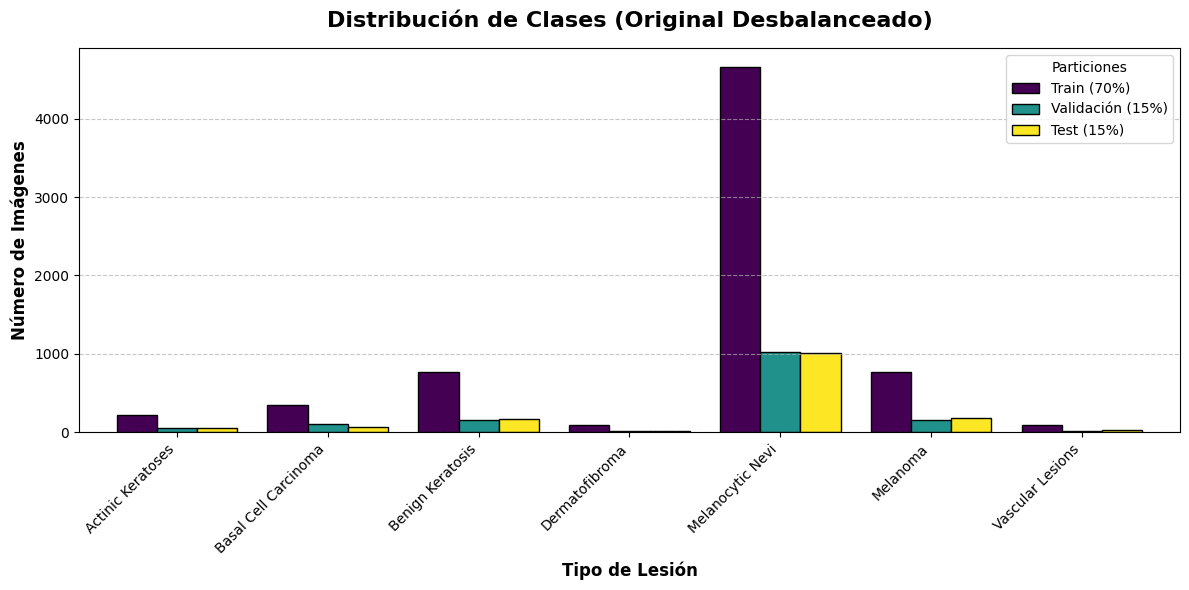

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Contar las ocurrencias de cada clase en cada partición
train_counts = pd.Series(train_labels).value_counts().sort_index()
val_counts = pd.Series(val_labels).value_counts().sort_index()
test_counts = pd.Series(test_labels).value_counts().sort_index()

# 2. Crear un DataFrame resumen para verlo bonito
dist_df = pd.DataFrame({
    'Train (70%)': train_counts,
    'Validación (15%)': val_counts,
    'Test (15%)': test_counts
})

# Reemplazamos el índice numérico (0 al 6) por los nombres reales de las carpetas
dist_df.index = class_names

print("📊 Distribución exacta de muestras por partición:")
display(dist_df) # 'display' lo formatea como una tabla bonita en Jupyter

print("-" * 60)
print(f"Totales -> Train: {len(train_labels)} | Val: {len(val_labels)} | Test: {len(test_labels)}")

# 3. Visualización Gráfica
plt.figure(figsize=(12, 6))
dist_df.plot(kind='bar', figsize=(12, 6), width=0.8, colormap='viridis', edgecolor='black')

plt.title('Distribución de Clases (Original Desbalanceado)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Tipo de Lesión', fontsize=12, fontweight='bold')
plt.ylabel('Número de Imágenes', fontsize=12, fontweight='bold')

# Rotar los nombres para que se lean bien
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Particiones')

plt.tight_layout()
plt.show()

<class 'pandas.core.frame.DataFrame'>
Index: 10015 entries, ISIC_0027419 to ISIC_0032258
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  object 
 1   dx            10015 non-null  object 
 2   dx_type       10015 non-null  object 
 3   age           9958 non-null   float64
 4   sex           10015 non-null  object 
 5   localization  10015 non-null  object 
dtypes: float64(1), object(5)
memory usage: 805.7+ KB
               age
count  9958.000000
mean     51.863828
std      16.968614
min       0.000000
25%      40.000000
50%      50.000000
75%      65.000000
max      85.000000


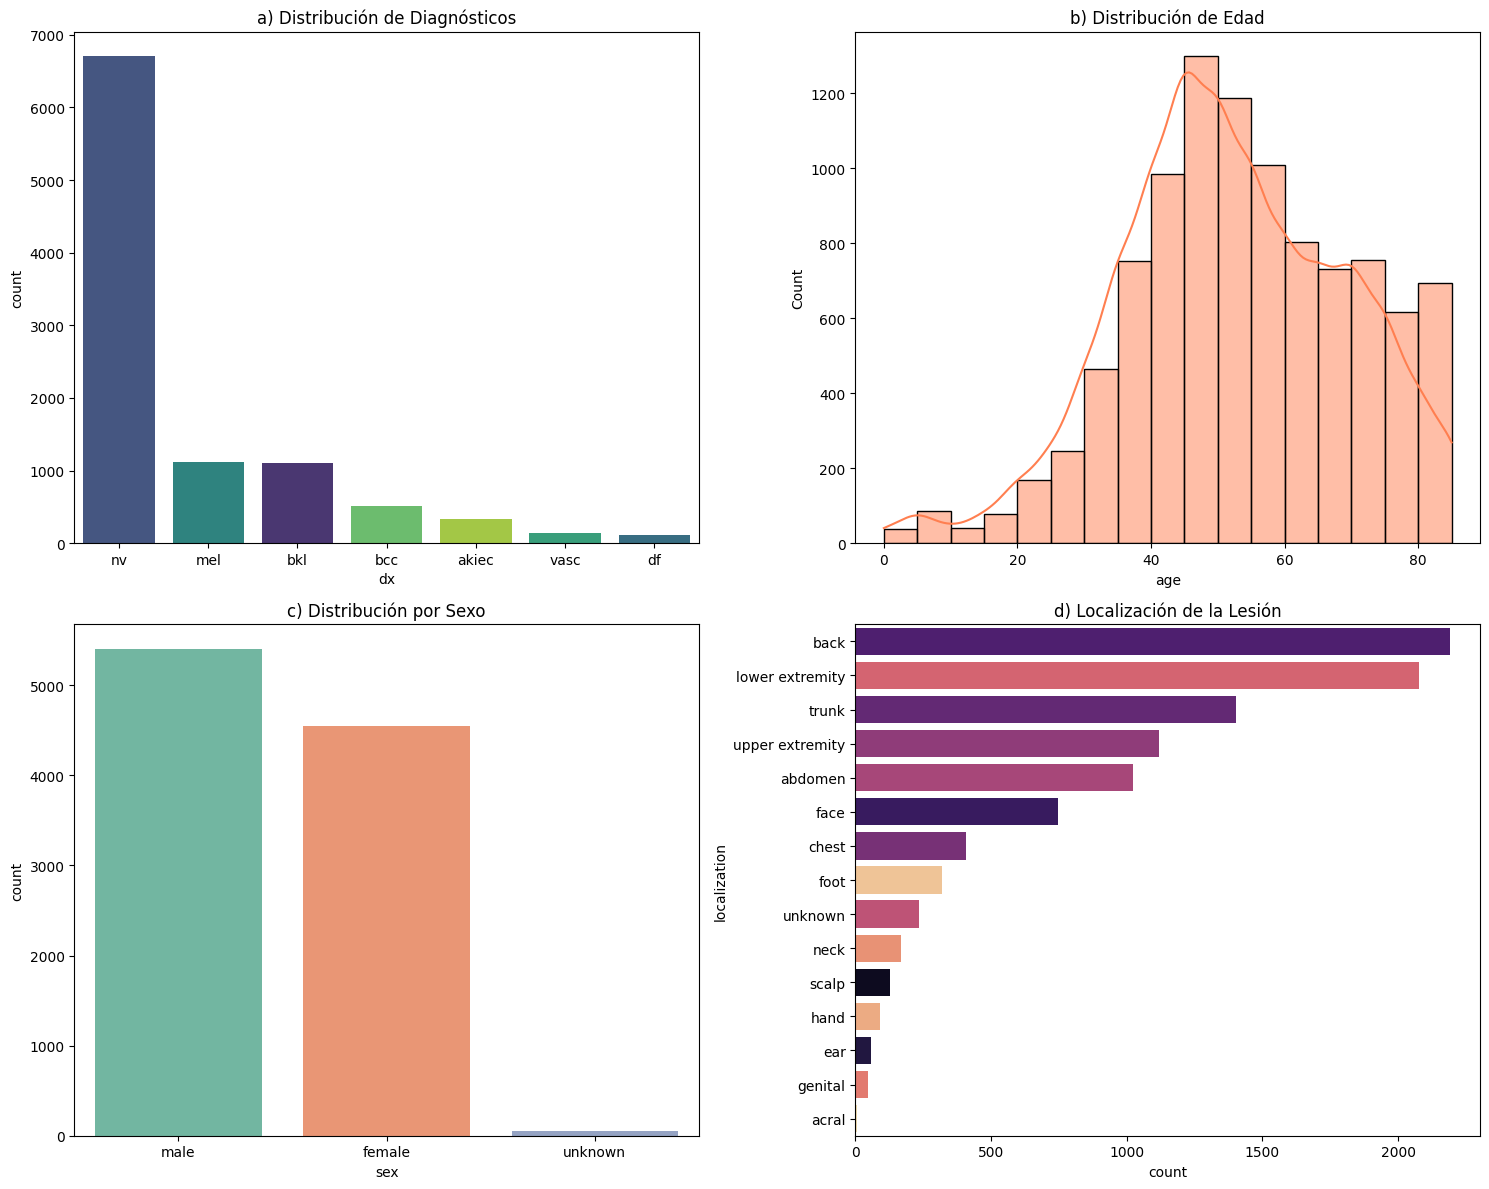

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

df.info()
print(df.describe())

# Preparamos el lienzo
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Gráfico 1: Diagnóstico (Ordenado para ver el desbalance)
# Solución: Añadimos hue='dx' y legend=False
sns.countplot(data=df, x='dx', hue='dx', order=df['dx'].value_counts().index, ax=axes[0, 0], palette='viridis', legend=False)
axes[0, 0].set_title('a) Distribución de Diagnósticos')

# Gráfico 2: Edad
# Este se queda igual, ya que histplot usa un color único ('color') y no una paleta ('palette')
sns.histplot(data=df, x='age', bins=17, kde=True, ax=axes[0, 1], color='coral')
axes[0, 1].set_title('b) Distribución de Edad')

# Gráfico 3: Sexo
# Solución: Añadimos hue='sex' y legend=False
sns.countplot(data=df, x='sex', hue='sex', order=df['sex'].value_counts().index, ax=axes[1, 0], palette='Set2', legend=False)
axes[1, 0].set_title('c) Distribución por Sexo')

# Gráfico 4: Localización
# Solución: Como aquí las barras son horizontales (y='localization'), el hue debe ser igual a 'localization'
sns.countplot(data=df, y='localization', hue='localization', order=df['localization'].value_counts().index, ax=axes[1, 1], palette='magma', legend=False)
axes[1, 1].set_title('d) Localización de la Lesión')

plt.tight_layout()
plt.show()

In [11]:
print("--- 1. RECUENTO DE VALORES ÚNICOS ---")
# nunique() nos dice cuántas opciones distintas hay por cada columna
print(df.nunique())

print("\n--- 2. ¿QUÉ HAY DENTRO DE LAS CATEGORÍAS? ---")
# Para las variables de texto, a veces queremos ver exactamente cuáles son esas opciones
columnas_interes = ['dx', 'dx_type', 'sex']
for col in columnas_interes:
    print(f"\nValores únicos en '{col}':")
    print(df[col].unique())

print("\n--- 3. DUPLICADOS ---")
# Primero, buscamos si hay filas donde ABSOLUTAMENTE TODO sea idéntico
filas_clonadas = df.duplicated().sum()
print(f"Filas 100% duplicadas (errores de registro): {filas_clonadas}")

# Y ahora, el detalle vital del HAM10000:
# ¿Hay alguna foto repetida? ¿Y cuántas pecas tienen múltiples fotos?
# FIXME: ARREGLAR ESTO
# fotos_duplicadas = df['image_id'].duplicated().sum()
lesiones_duplicadas = df['lesion_id'].duplicated().sum()

# print(f"Imágenes con el mismo ID (fotos repetidas): {fotos_duplicadas}")
print(f"Lesiones con el mismo ID (misma lesión, varias fotos): {lesiones_duplicadas}")

--- 1. RECUENTO DE VALORES ÚNICOS ---
lesion_id       7470
dx                 7
dx_type            4
age               18
sex                3
localization      15
dtype: int64

--- 2. ¿QUÉ HAY DENTRO DE LAS CATEGORÍAS? ---

Valores únicos en 'dx':
['bkl' 'nv' 'df' 'mel' 'vasc' 'bcc' 'akiec']

Valores únicos en 'dx_type':
['histo' 'consensus' 'confocal' 'follow_up']

Valores únicos en 'sex':
['male' 'female' 'unknown']

--- 3. DUPLICADOS ---
Filas 100% duplicadas (errores de registro): 2543
Lesiones con el mismo ID (misma lesión, varias fotos): 2545


Creamos la función que leerá tanto la imagen como los metadatos

In [12]:
def process_data(image_path, metadata, label):
    # Procesar imagen
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    
    # El modelo esperará un diccionario o una tupla de entradas: (imagen, metadatos)
    return (img, metadata), tf.one_hot(label, depth=7)

# Dataset de Entrenamiento
train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_meta, train_labels))
train_ds = train_ds.shuffle(len(train_paths))
train_ds = train_ds.map(process_data, num_parallel_calls=AUTOTUNE)
train_ds = train_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

# Dataset de Validación
val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_meta, val_labels))
val_ds = val_ds.map(process_data, num_parallel_calls=AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

class_names_es = get_class_name_es(class_names)

print(f"✅ Clases detectadas (IDs): {class_names}")
print(f"🇪🇸 Traducción: {class_names_es}")


# Optimización para la GPU (Crucial para no tener cuellos de botella)
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)


✅ Clases detectadas (IDs): ['Actinic Keratoses', 'Basal Cell Carcinoma', 'Benign Keratosis', 'Dermatofibroma', 'Melanocytic Nevi', 'Melanoma', 'Vascular Lesions']
🇪🇸 Traducción: ['Queratosis actínica', 'Carcinoma basocelular', 'Queratosis benigna', 'Dermatofibroma', 'Nevus melanocítico', 'Melanoma', 'Lesión vascular']


## 5: Visualización de muestras

📸 Generando galería de presentación (un ejemplo por clase)...


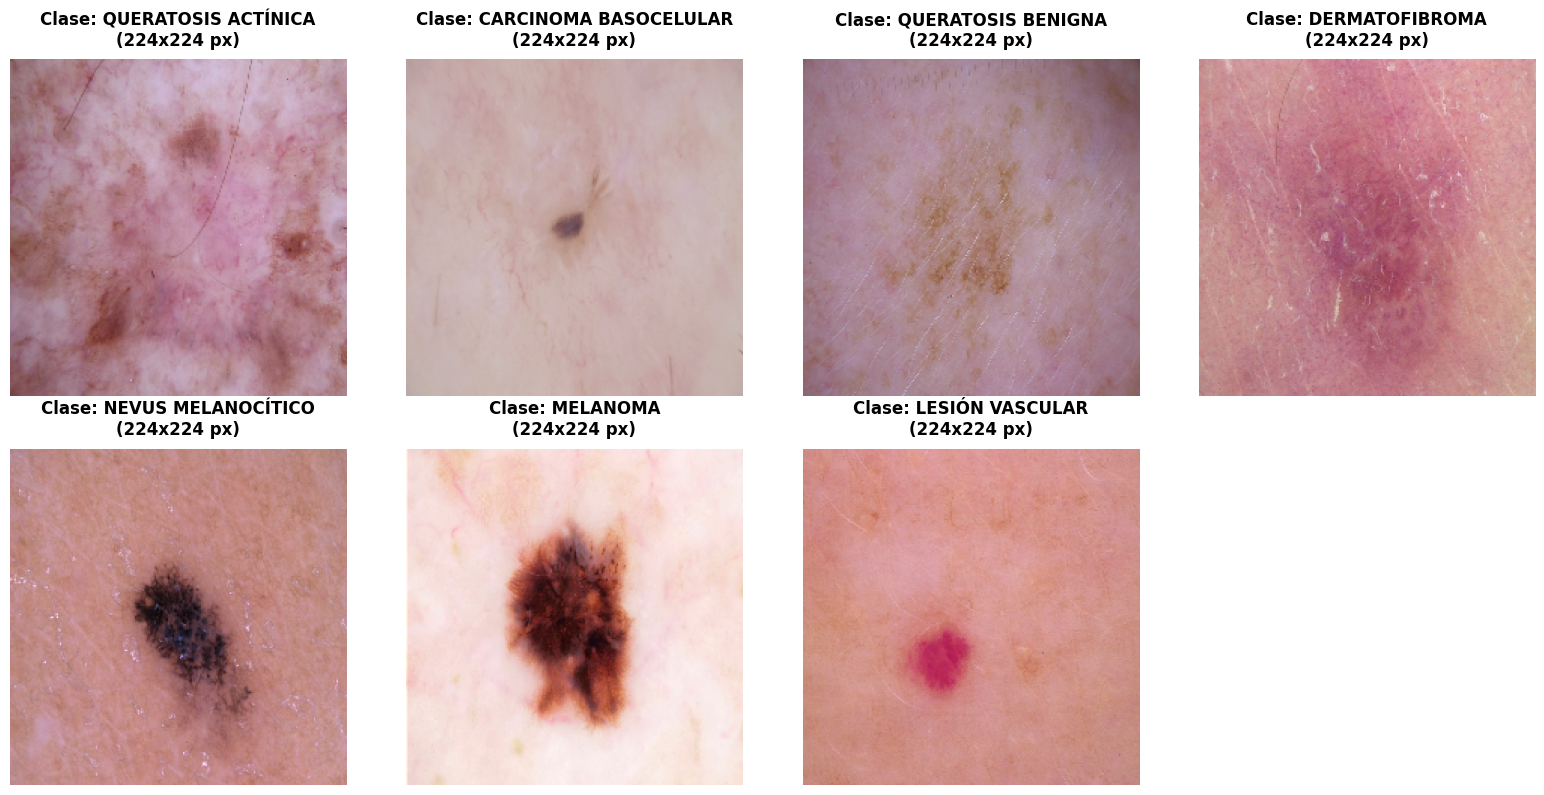

In [13]:
import matplotlib.pyplot as plt

# Configuración de la galería
plt.figure(figsize=(16, 8))
cols = 4
rows = (len(class_names) + cols - 1) // cols

print("📸 Generando galería de presentación (un ejemplo por clase)...")

for i, class_name in enumerate(sorted(class_names)):
    # Ruta a la carpeta de la clase
    class_path = os.path.join(DATA_PATH, class_name)
    # Tomamos la primera imagen que encontremos
    img_name = os.listdir(class_path)[0]
    img_path = os.path.join(class_path, img_name)
    
    # Cargar y procesar imagen para mostrar
    img = tf.keras.utils.load_img(img_path, target_size=IMG_SIZE)
    img_array = tf.keras.utils.img_to_array(img).astype("uint8")
    
    ax = plt.subplot(rows, cols, i + 1)
    plt.imshow(img_array)
    
    # Título elegante con Nombre y Resolución
    plt.title(f"Clase: {get_class_name_es(class_name).upper()}\n({IMG_SIZE[0]}x{IMG_SIZE[1]} px)", 
              fontsize=12, fontweight='bold', pad=10)
    plt.axis("off")

plt.tight_layout()
plt.show()

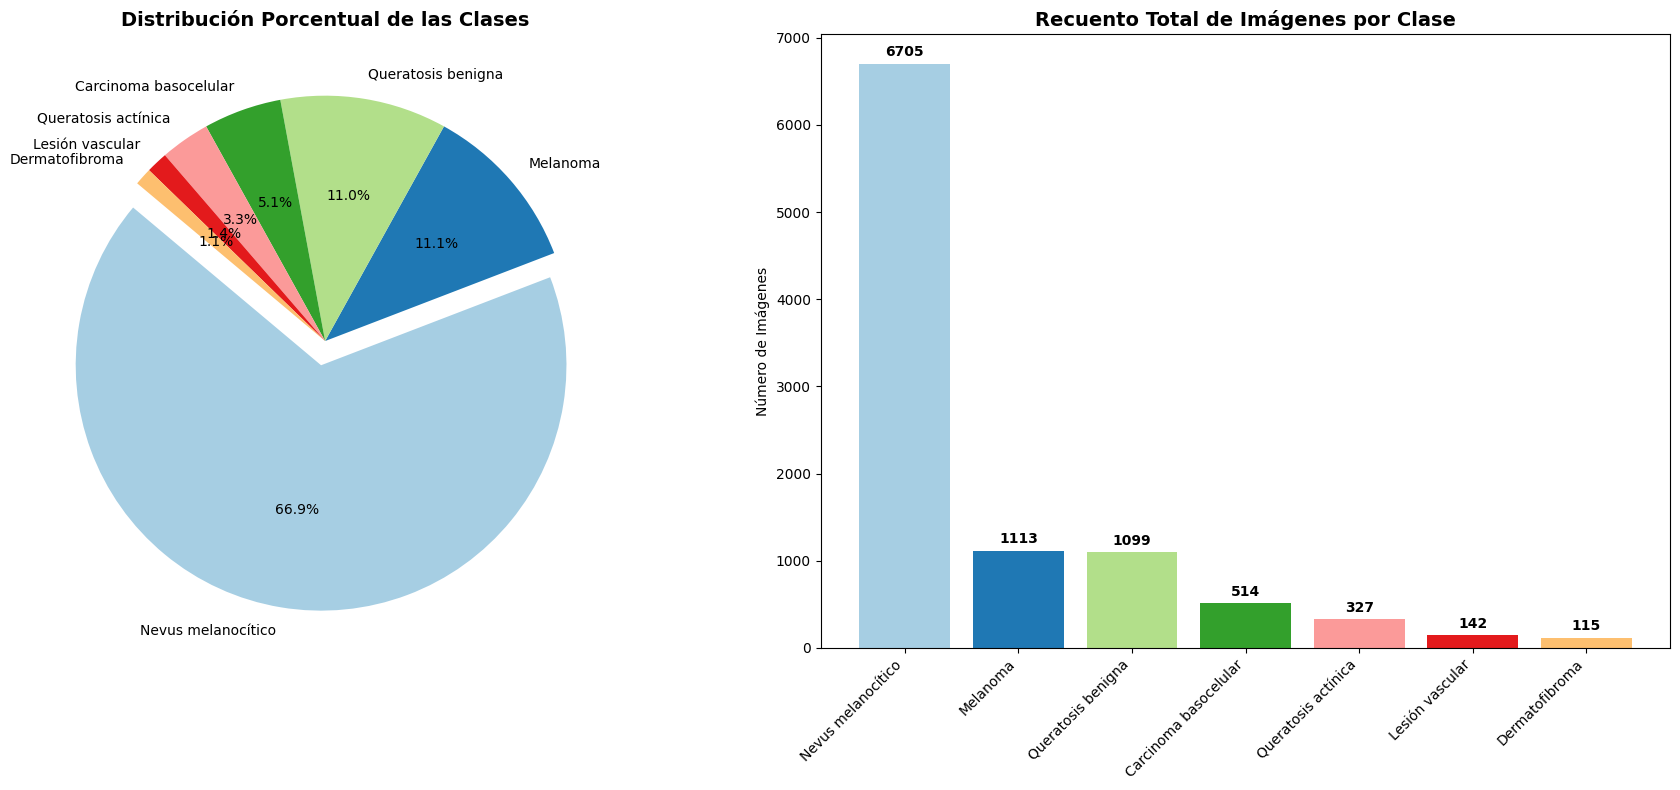


📋 Resumen Estadístico del Dataset (en español):
                 Tipo  Cantidad  Porcentaje
   Nevus melanocítico      6705       66.95
             Melanoma      1113       11.11
   Queratosis benigna      1099       10.97
Carcinoma basocelular       514        5.13
  Queratosis actínica       327        3.27
      Lesión vascular       142        1.42
       Dermatofibroma       115        1.15


In [14]:
# 1. Contar archivos por carpeta
stats = {}
for class_name in class_names:
    class_path = os.path.join(DATA_PATH, class_name)
    stats[class_name] = len(os.listdir(class_path))

# 2. Crear DataFrame y TRADUCIR
df_stats = pd.DataFrame(list(stats.items()), columns=['Tipo', 'Cantidad'])

# --- APLICAMOS LA TRADUCCIÓN AQUÍ ---
df_stats['Tipo'] = df_stats['Tipo'].apply(get_class_name_es)
# ------------------------------------

df_stats = df_stats.sort_values(by='Cantidad', ascending=False)
df_stats['Porcentaje'] = (df_stats['Cantidad'] / df_stats['Cantidad'].sum() * 100).round(2)

# 3. Visualización
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8)) # Aumentado un poco el alto

# Gráfico de Tarta
colors = plt.cm.Paired(range(len(class_names)))
wedges, texts, autotexts = ax1.pie(df_stats['Cantidad'], labels=df_stats['Tipo'], 
                                   autopct='%1.1f%%', startangle=140, colors=colors,
                                   explode=[0.1 if i == 0 else 0 for i in range(len(df_stats))])
ax1.set_title("Distribución Porcentual de las Clases", fontsize=14, fontweight='bold')

# Gráfico de Barras
bars = ax2.bar(df_stats['Tipo'], df_stats['Cantidad'], color=colors)
ax2.set_title("Recuento Total de Imágenes por Clase", fontsize=14, fontweight='bold')
ax2.set_ylabel("Número de Imágenes")

# Rotar etiquetas para que no se solapen los nombres en español
plt.sca(ax2)
plt.xticks(rotation=45, ha='right')

# Añadir etiquetas de cantidad sobre las barras
for bar in bars:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, yval + 50, yval, ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Mostrar tabla resumen
print("\n📋 Resumen Estadístico del Dataset (en español):")
print(df_stats.to_string(index=False))

## 5: Búsqueda de hiperparámetros

Primero configuramos Optuna como optimizador:

In [15]:
import optuna
storage_name = "sqlite:///optuna_tfm.db"
print(f"✅ Optuna DB lista en {storage_name}")

✅ Optuna DB lista en sqlite:///optuna_tfm.db


In [16]:
import numpy as np
from keras_cv_attention_models import coatnet
from optuna_integration import TFKerasPruningCallback
from tensorflow.keras import layers, models
from sklearn.utils.class_weight import compute_class_weight
import keras_cv_attention_models
import wandb
from wandb.integration.keras import WandbMetricsLogger, WandbModelCheckpoint
import gc
import datetime
import time
import optuna
import tensorflow as tf
import traceback

MODEL_NAME = "CoAtNet0"
# Cambiamos el nombre del estudio para reflejar la hipótesis exacta
STUDY_NAME = "Global_CPU_Augmentation_Trainable_Base" 
print(f"🚀 Lanzando estudio de Optuna: {STUDY_NAME}")

BASE_CONFIG = {
    # 1. Metadatos y Entorno
    "model_architecture": MODEL_NAME,
    "study_name": STUDY_NAME,
    "dataset": "HAM10000",
    "keras_mode": "Legacy (TF_USE_LEGACY_KERAS=1)",
    "precision": "float32",
    "base_model_trainable": "True",
    
    # 2. Entradas
    "img_size": 224,
    "batch_size": BATCH_SIZE,
    
    # 3. Estrategia de Splitting
    "split_method": "GroupShuffleSplit",
    "split_group": "lesion_id",
    "test_size": 0.15,
    "val_size": 0.176,
    "random_state": 42,
    
    # 4. Pipeline de Preprocesamiento
    "tabular_imputation": "Media (Age)",
    "tabular_scaling": "StandardScaler",
    "tabular_encoding": "OneHotEncoder (handle_unknown='ignore')",
    "image_normalization": "Division por 255.0",
    
    # 5. Balanceo de Clases (Integrado en Focal Loss)
    "class_balancing_method": "sklearn.utils.class_weight (balanced)",
    "class_weight_multipliers": "Manual: {0:1.2, 1:1.4, 3:0.5, 5:1.5}",
    "loss_function": "CategoricalFocalCrossentropy",
    "focal_loss_gamma": 2.0,
    
    # 6. Data Augmentation
    "augmentation_strategy": "Random Crop & Resize (TF Puro CPU) + Rotación 90º",
    "augmentation_scope": "Global (todas las clases)",
    "augmentation_implementation": "tf.data pipeline .map()",
    "augmentation_location": "Fuera del trial de Optuna"
}

notas = """
**Objetivo/Hipótesis:** Sacar el pipeline de Data Augmentation (operaciones puras CPU) fuera de Optuna para ahorrar overhead, manteniendo el modelo base entrenable para no perder precisión.

**Siguientes pasos / Tareas pendientes:**
- Subir el batchsize -> Probar a ver si aumenta el rendimiento del modelo y cuánto tarda cada época.
- Probar Mixed Precision (`float16` con softmax en `float32`) para exprimir el batch size -> aumentar la velocidad sin perder rendimiento del modelo
- Descongelar algunas capas del modelo base -> ver si el modelo aumenta el rendimiento
"""

# --- 1. CÁLCULO DE PESOS ---
pesos_balanceados = compute_class_weight(
    class_weight='balanced', 
    classes=np.unique(train_labels), 
    y=train_labels
)

alpha_weights = list(pesos_balanceados.astype(np.float32))

# Ajustes manuales
alpha_weights[0] *= 1.2 # Queratosis Actínica
alpha_weights[1] *= 1.4 # BCC
alpha_weights[5] *= 1.5 # Melanoma
alpha_weights[3] *= 0.5 # Dividimos su penalización a la mitad

print("📊 Pesos calculados para cada clase (Alpha):")
for i, peso in enumerate(alpha_weights):
    print(f"Clase {i}: {peso:.4f}")

# --- 2. PIPELINE GLOBAL Y DATA AUGMENTATION (PURO CPU) ---
ZOOM_FACTOR = 0.10
ROTATION_PROB = 0.5

def augment_stateless(image):
    # Rotación segura (Múltiplos de 90º)
    if tf.random.uniform([]) < ROTATION_PROB:
        image = tf.image.rot90(image, k=tf.random.uniform([], 0, 4, tf.int32))
    
    # Zoom aleatorio (Crop + Resize puro de TF). Equivalente matemático seguro a RandomZoom.
    if ZOOM_FACTOR > 0:
        scale = tf.random.uniform([], 1.0 - ZOOM_FACTOR, 1.0)
        new_size = tf.cast(224.0 * scale, tf.int32)
        image = tf.image.random_crop(image, size=[new_size, new_size, 3])
        image = tf.image.resize(image, [224, 224])
        
    return image

# Compilamos el dataset FUERA del trial.
# Al usar map puro con AUTOTUNE, esto se ejecutará asíncronamente en los hilos de la CPU.
train_ds_aug = tf.data.Dataset.from_tensor_slices((train_paths, train_meta, train_labels))
train_ds_aug = train_ds_aug.shuffle(2000).map(process_data, num_parallel_calls=tf.data.AUTOTUNE)
train_ds_aug = train_ds_aug.map(
    lambda inputs, label: ((augment_stateless(inputs[0]), inputs[1]), label),
    num_parallel_calls=tf.data.AUTOTUNE
).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE) # Nota: Asegúrate de tener BATCH_SIZE definido en el scope global.

# --- 3. CALLBACKS GLOBALES ---

class WandbTimeCallback(tf.keras.callbacks.Callback):
    def __init__(self):
        super().__init__()
        self.epoch_times = []

    def on_epoch_begin(self, epoch, logs=None):
        # Guardamos el instante exacto en el que empieza la época
        self.start_time = time.time()
        hora_actual = datetime.datetime.now().strftime("%H:%M:%S")
        print(f"\n⏰ Inicio Época {epoch + 1}: {hora_actual}")

    def on_epoch_end(self, epoch, logs=None):
        # Calculamos los segundos transcurridos
        duration = time.time() - self.start_time
        self.epoch_times.append(duration)
        
        hora_actual = datetime.datetime.now().strftime("%H:%M:%S")
        print(f"✅ Fin Época {epoch + 1}: {hora_actual} (Duración: {duration:.2f}s)")
        
        # 1. Registrar en W&B el tiempo de ESTA época
        wandb.log({"epoch_duration_seconds": duration, "epoch": epoch}, commit=False)

    def on_train_end(self, logs=None):
        # 2. Registrar en W&B el tiempo MEDIO al terminar el trial/entrenamiento final
        if self.epoch_times:
            avg_time = sum(self.epoch_times) / len(self.epoch_times)
            wandb.run.summary["avg_epoch_duration_seconds"] = avg_time
            print(f"📊 Resumen del Trial -> Tiempo medio por época: {avg_time:.2f} segundos")

# --- 4. FUNCIÓN OBJETIVO OPTUNA ---
def objective(trial):
    try:
        # Limpiar memoria del Trial anterior CRÍTICO
        tf.keras.backend.clear_session()
        gc.collect()

        # HIPERPARÁMETROS
        lr = trial.suggest_float("learning_rate", 1e-5, 5e-4, log=True)
        dropout = trial.suggest_float("dropout", 0.2, 0.5)
        meta_units = trial.suggest_int("meta_units", 16, 32)
        meta_layers = trial.suggest_int("meta_layers", 1, 3)

        trial_config = {
            **BASE_CONFIG,
            "hipotesis": "Búsqueda Optuna (Augmentation Global)",
            "learning_rate": lr,           
            "dropout": dropout,
            "meta_units": meta_units,
            "meta_layers": meta_layers,
        }

        wandb.init(
            project="TFM_Melanoma",
            name=f"Trial_{trial.number}",
            group=STUDY_NAME,
            job_type="hyperparameter_optimization", 
            tags=["optuna", "cpu_augmentation", MODEL_NAME],
            save_code=True,
            config=trial_config,
            notes = notas
        )

        # MODELO
        input_img = layers.Input(shape=(224, 224, 3), name="image_input")
        
        # Mantenemos trainable=True como requisito innegociable para la precisión
        base_model = keras_cv_attention_models.coatnet.CoAtNet0(
            input_shape=(224, 224, 3), num_classes=0, pretrained="imagenet"
        )
        base_model.trainable = True 
        
        img_features = layers.GlobalAveragePooling2D()(base_model(input_img))

        input_meta = layers.Input(shape=(19,), name="meta_input")
        x_meta = input_meta
        for i in range(meta_layers):
            x_meta = layers.Dense(meta_units, activation="relu")(x_meta)
            x_meta = layers.BatchNormalization()(x_meta)

        combined = layers.Concatenate()([img_features, x_meta])
        x = layers.Dense(256, activation="relu")(combined)
        x = layers.Dropout(dropout)(x)
        output = layers.Dense(7, activation="softmax")(x)

        model = models.Model(inputs=[input_img, input_meta], outputs=output)
        
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
            loss=tf.keras.losses.CategoricalFocalCrossentropy(alpha=alpha_weights, gamma=2.0),
            metrics=[
                'accuracy',
                tf.keras.metrics.Recall(class_id=4, name='recall_melanoma'),     
                tf.keras.metrics.Recall(class_id=1, name='recall_bcc'),          
                tf.keras.metrics.Recall(class_id=0, name='recall_actinica')      
            ],
        )

        # CALLBACKS DEL TRIAL
        lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6, verbose=0
        )
        
        early_stop = tf.keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=8, restore_best_weights=True, verbose=0
        )
        
        timestamp_cb = WandbTimeCallback()

        # ENTRENAMIENTO
        history = model.fit(
            train_ds_aug, # Usamos el Dataset Global ya compilado
            validation_data=val_ds, 
            epochs=50, 
            callbacks=[
                lr_scheduler,
                early_stop, 
                timestamp_cb,
                TFKerasPruningCallback(trial, "val_loss"), 
                WandbMetricsLogger()
            ],
            verbose=0
        )

        return min(history.history["val_loss"])

    except optuna.exceptions.TrialPruned as e:
        raise e

    except Exception as e:
        print(f"\n❌ FUEGO! El Trial {trial.number} ha crasheado:")
        print(traceback.format_exc()) 
        raise e
    
    finally:
        # Corrección de la Fuga de Memoria
        if 'model' in locals():
            del model
        if 'base_model' in locals():
            del base_model
        
        wandb.finish()
        tf.keras.backend.clear_session()
        gc.collect()

# Lanzar el estudio
study = optuna.create_study(
    direction="minimize", 
    storage=storage_name, 
    study_name=STUDY_NAME, 
    load_if_exists=True
)

🚀 Lanzando estudio de Optuna: Global_CPU_Augmentation_Trainable_Base
📊 Pesos calculados para cada clase (Alpha):
Clase 0: 5.3768
Clase 1: 3.9903
Clase 2: 1.2918
Clase 3: 5.4061
Clase 4: 0.2132
Clase 5: 1.9352
Clase 6: 10.5821


[I 2026-05-25 14:49:48,460] Using an existing study with name 'Global_CPU_Augmentation_Trainable_Base' instead of creating a new one.


Ahora empezamos los trials del entrenamiento. Con el parámetro skip_training a "True" podemos saltarlo y usar el mejor modelo ya entrenado.

In [17]:
optuna.logging.set_verbosity(optuna.logging.DEBUG)

# --- CONFIGURACIÓN DE FLUJO ---
SKIP_TRAINING = True     # True: Carga el modelo | False: Entrena
RUN_OPTIMIZATION = False   # True: Busca mejores parámetros | False: Usa los mejores ya encontrados o defaults
TRAIN_FINAL_MODEL = True  # True: Entrena el modelo final con los mejores parámetros | False: Solo carga
TRIALS = 15                                                                                                     
 
 # 1. EJECUCIÓN DE OPTUNA
if not SKIP_TRAINING and RUN_OPTIMIZATION:
    print(f"🔥 Lanzando optimización con Optuna (n_trials={TRIALS})...")
    study.optimize(objective, n_trials=TRIALS)
    print("✅ Optimización completada.")
    
    # Vaciamos la memoria del último modelo de Optuna para dejar sitio al Modelo Final
    tf.keras.backend.clear_session()
    gc.collect()

# 2. SELECCIÓN DE PARÁMETROS
# Filtramos para ver si hay algún trial que haya terminado con éxito
completed_trials = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]

if len(completed_trials) > 0:
    best_params = study.best_params
    print(f"📈 Usando mejores parámetros encontrados por Optuna:")
    for key, value in best_params.items():
        print(f"   - {key}: {value}")
else:
    best_params = {
        'learning_rate': 1e-4, 
        'dropout': 0.3, 
        'meta_units': 32,       
        'meta_layers': 2,       
        'zoom_factor': 0.1,     
        'rotation_prob': 0.5    
    }
    print(f"⚠️ No hay historial de éxito en la DB. Usando parámetros por defecto: {best_params}")

📈 Usando mejores parámetros encontrados por Optuna:
   - learning_rate: 3.2187601330950077e-05
   - dropout: 0.2386945134537422
   - meta_units: 28
   - meta_layers: 2


## 7. Entrenamiento del modelo final

In [18]:
MODEL_PATH = f'models/{STUDY_NAME}.keras' # Ojo: he quitado la barra inicial (/) para que no intente guardar en la raíz del disco duro

if TRAIN_FINAL_MODEL:
    # 1. Recuperar los mejores parámetros (Solo los que Optuna optimizó)
    if 'best_params' not in locals():
        best_params = {
            'learning_rate': 1e-4, 'dropout': 0.3, 'meta_units': 32, 'meta_layers': 2
        }
    print(f"🏆 Mejores parámetros a usar: {best_params}")

    # ==========================================
    # APLICAR EL DATA AUGMENTATION FIJO (PURO CPU)
    # ==========================================
    FINAL_ZOOM_FACTOR = 0.10
    FINAL_ROTATION_PROB = 0.5

    final_config = {
        **BASE_CONFIG,
        **best_params  # <-- Inyecta automáticamente lr, dropout, meta_units, etc.
    }

    wandb.init(
        project="TFM_Melanoma", 
        name=f"Final_Model_{STUDY_NAME}",
        config=final_config,
        group=f"{STUDY_NAME}_Final",
        job_type="final_training", 
        tags=["optuna", "cpu_augmentation", MODEL_NAME],
        save_code=True,
        notes = notas
    )
    
    # ELIMINAMOS la capa RandomZoom de Keras
    # implementamos la función stateless y pura para TF Data
    def final_augment_fn(image):
        # Rotación de 90º aleatoria
        if tf.random.uniform([]) < FINAL_ROTATION_PROB:
            image = tf.image.rot90(image, k=tf.random.uniform([], 0, 4, tf.int32))
            
        # Zoom aleatorio (Crop + Resize) en CPU
        if FINAL_ZOOM_FACTOR > 0:
            scale = tf.random.uniform([], 1.0 - FINAL_ZOOM_FACTOR, 1.0)
            new_size = tf.cast(224.0 * scale, tf.int32)
            image = tf.image.random_crop(image, size=[new_size, new_size, 3])
            image = tf.image.resize(image, [224, 224])
            
        return image

    print("🔄 Generando Dataset Final con Data Augmentation (CPU-Only)...")
    train_ds_final = tf.data.Dataset.from_tensor_slices((train_paths, train_meta, train_labels))
    train_ds_final = train_ds_final.shuffle(len(train_paths)).map(process_data, num_parallel_calls=tf.data.AUTOTUNE)
    train_ds_final = train_ds_final.map(
        lambda inputs, label: ((final_augment_fn(inputs[0]), inputs[1]), label),
        num_parallel_calls=tf.data.AUTOTUNE
    ).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

    # ==========================================
    # 2. Reconstruir la arquitectura ganadora
    # ==========================================
    input_img = layers.Input(shape=(224, 224, 3), name="image_input")
    base_model = keras_cv_attention_models.coatnet.CoAtNet0(
        input_shape=(224, 224, 3), num_classes=0, pretrained="imagenet"
    )
    base_model.trainable = True # Permitimos fine-tuning para aprender características dermatológicas
    img_output = base_model(input_img)
    img_features = layers.GlobalAveragePooling2D()(img_output)

    input_meta = layers.Input(shape=(19,), name="meta_input")
    x_meta = input_meta
    for _ in range(best_params['meta_layers']):
        x_meta = layers.Dense(best_params['meta_units'], activation="relu")(x_meta)
        x_meta = layers.BatchNormalization()(x_meta)

    combined = layers.Concatenate()([img_features, x_meta])
    x = layers.Dense(256, activation="relu")(combined)
    x = layers.Dropout(best_params['dropout'])(x)
    output = layers.Dense(7, activation="softmax")(x)

    final_model = models.Model(inputs=[input_img, input_meta], outputs=output)

    # ==========================================
    # 3. Compilar (ENFOQUE MÉDICO)
    # ==========================================
    final_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=best_params['learning_rate']),
        loss=tf.keras.losses.CategoricalFocalCrossentropy(alpha=alpha_weights, gamma=2.0),
        metrics=[
            "accuracy",
            tf.keras.metrics.Recall(class_id=4, name='recall_melanoma'),
            tf.keras.metrics.Recall(class_id=1, name='recall_bcc'),
            tf.keras.metrics.Recall(class_id=0, name='recall_actinica')
        ],
        jit_compile=False # Añadido por seguridad anti-OOM en el entrenamiento final
    )

    final_model.summary()

    timestamp_cb = WandbTimeCallback()

    # ==========================================
    # 4. Callbacks y Entrenamiento
    # ==========================================
    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss', 
            patience=10, 
            restore_best_weights=True
        ),
        tf.keras.callbacks.ModelCheckpoint(
            filepath=MODEL_PATH,
            monitor='val_loss',     # Cambiamos esto: monitorizamos la pérdida focal
            save_best_only=True,
            mode='min',             # Queremos que la pérdida sea la MÍNIMA
            verbose=1
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.2, patience=4, min_lr=1e-6, verbose=1
        ),
        WandbMetricsLogger(),
        timestamp_cb
    ]

    print("🚀 Entrenando el modelo definitivo...")
    final_model.fit(
        train_ds_final,
        validation_data=val_ds,
        epochs=60, 
        callbacks=callbacks
    )
    
    final_model.save("models/modelo_tfm_balanceado_backup.keras")

else:
    if os.path.exists(MODEL_PATH):
        print(f"📦 Cargando modelo final desde {MODEL_PATH}...")
        final_model = tf.keras.models.load_model(
            MODEL_PATH, 
            custom_objects={"CategoricalFocalCrossentropy": tf.keras.losses.CategoricalFocalCrossentropy}
        )
    else:
        print(f"❌ ERROR: TRAIN_FINAL_MODEL es False pero no encuentro {MODEL_PATH}")

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.


🏆 Mejores parámetros a usar: {'learning_rate': 3.2187601330950077e-05, 'dropout': 0.2386945134537422, 'meta_units': 28, 'meta_layers': 2}


wandb: Currently logged in as: herraiz92 (herraiz92-hospital-universitario-de-canarias) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


🔄 Generando Dataset Final con Data Augmentation (CPU-Only)...
>>>> Load pretrained from: /home/herraiz/.keras/models/coatnet0_224_imagenet.h5
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 meta_input (InputLayer)     [(None, 19)]                 0         []                            
                                                                                                  
 dense (Dense)               (None, 28)                   560       ['meta_input[0][0]']          
                                                                                                  
 image_input (InputLayer)    [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 batch_normalization (Batch  (None, 28)            

2026-05-25 14:50:16.385845: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:465] Loaded cuDNN version 8907
I0000 00:00:1779717019.505885  228226 service.cc:145] XLA service 0x7d9f703936c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779717019.505975  228226 service.cc:153]   StreamExecutor device (0): NVIDIA GeForce RTX 3080 Ti, Compute Capability 8.6
2026-05-25 14:50:19.511315: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1779717019.646120  228226 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


218/218 [==============================] - ETA: 0s - loss: 0.9203 - accuracy: 0.4907 - recall_melanoma: 0.3370 - recall_bcc: 0.2980 - recall_actinica: 0.1982
Epoch 1: val_loss improved from inf to 0.70482, saving model to models/Global_CPU_Augmentation_Trainable_Base.keras
✅ Fin Época 1: 14:51:36 (Duración: 104.25s)
218/218 [==============================] - 104s 298ms/step - loss: 0.9203 - accuracy: 0.4907 - recall_melanoma: 0.3370 - recall_bcc: 0.2980 - recall_actinica: 0.1982 - val_loss: 0.7048 - val_accuracy: 0.6039 - val_recall_melanoma: 0.5527 - val_recall_bcc: 0.3030 - val_recall_actinica: 0.0351 - lr: 3.2188e-05

⏰ Inicio Época 2: 14:51:37
Epoch 2/60
218/218 [==============================] - ETA: 0s - loss: 0.4595 - accuracy: 0.6793 - recall_melanoma: 0.5736 - recall_bcc: 0.6533 - recall_actinica: 0.4955
Epoch 2: val_loss improved from 0.70482 to 0.65586, saving model to models/Global_CPU_Augmentation_Trainable_Base.keras
✅ Fin Época 2: 14:52:37 (Duración: 60.42s)
218/218 [===

## 8: Predicciones
En esta celda extraemos las etiquetas reales y generamos las predicciones del modelo sobre el set de validación.

In [ ]:
def get_predictions(dataset, name=""):
    print(f"🔮 Generando predicciones sobre el set de {name}...")
    y_true = []
    y_pred = []
    
    # Iteramos sobre el dataset para obtener imágenes, metadatos y etiquetas reales
    for (images, meta), labels in dataset:
        # Predicción del modelo híbrido
        preds = final_model.predict((images, meta), verbose=0)
        
        # Guardamos la realidad (argmax de one-hot) y la predicción
        y_true.extend(np.argmax(labels.numpy(), axis=1))
        y_pred.extend(np.argmax(preds, axis=1))
        
    return np.array(y_true), np.array(y_pred)

# Definimos el nombre del archivo donde vivirán las variables
ARCHIVO_PREDICCIONES = "predicciones_modelo_hibrido.npz"

if TRAIN_FINAL_MODEL:
    # 1. Generamos las de ENTRENAMIENTO
    y_true_train, y_pred_train = get_predictions(train_ds, name="ENTRENAMIENTO")
    wandb.log({
    "Matriz_Confusion_Train": wandb.plot.confusion_matrix(
        probs=None,
        y_true=y_true_train, 
        preds=y_pred_train,
        class_names=class_names_es
    )
})

    # 2. Generamos las de VALIDACIÓN
    y_true_val, y_pred_val = get_predictions(val_ds, name="VALIDACIÓN")
    wandb.log({
    "Matriz_Confusion_Val": wandb.plot.confusion_matrix(
        probs=None,
        y_true=y_true_val, 
        preds=y_pred_val,
        class_names=class_names_es
    )
})

    # 3. Generamos las de TEST
    y_true_test, y_pred_test = get_predictions(test_ds, name="TEST")
    wandb.log({
    "Matriz_Confusion_Test": wandb.plot.confusion_matrix(
        probs=None,
        y_true=y_true_test, 
        preds=y_pred_test,
        class_names=class_names_es
    )
})
    
    # --- GUARDAMOS LAS VARIABLES EN DISCO ---
    np.savez(ARCHIVO_PREDICCIONES, 
             y_true_train=y_true_train, y_pred_train=y_pred_train,
             y_true_val=y_true_val, y_pred_val=y_pred_val,
             y_true_test=y_true_test, y_pred_test=y_pred_test)
    
    print(f"✅ Predicciones guardadas correctamente en '{ARCHIVO_PREDICCIONES}'")
    print(f"📊 Análisis completado. Entrenamiento: {len(y_true_train)} imágenes | Validación: {len(y_true_val)} imágenes | Test: {len(y_true_test)} imágenes.")

else:
    # --- CARGAMOS LAS VARIABLES DESDE EL DISCO ---
    if os.path.exists(ARCHIVO_PREDICCIONES):
        print(f"📦 Cargando predicciones previas desde '{ARCHIVO_PREDICCIONES}'...")
        datos = np.load(ARCHIVO_PREDICCIONES)
        
        # Extraemos las variables para que estén disponibles en el entorno
        y_true_train = datos['y_true_train']
        y_pred_train = datos['y_pred_train']
        y_true_val   = datos['y_true_val']
        y_pred_val   = datos['y_pred_val']
        y_true_test  = datos['y_true_test']
        y_pred_test  = datos['y_pred_test']
        
        print(f"✅ Predicciones cargadas en memoria con éxito.")
        print(f"📊 Datos listos. Entrenamiento: {len(y_true_train)} imágenes | Validación: {len(y_true_val)} imágenes | Test: {len(y_true_test)} imágenes.")
        
    else:
        print(f"⚠️ No se encontró el archivo '{ARCHIVO_PREDICCIONES}'. Generándolas sobre la marcha...")
        # Generación de emergencia si falta el archivo
        y_true_train, y_pred_train = get_predictions(train_ds, name="ENTRENAMIENTO")
        y_true_val, y_pred_val     = get_predictions(val_ds, name="VALIDACIÓN")
        y_true_test, y_pred_test   = get_predictions(test_ds, name="TEST")

🔮 Generando predicciones sobre el set de ENTRENAMIENTO...


2026-05-25 15:09:29.294799: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


🔮 Generando predicciones sobre el set de VALIDACIÓN...


2026-05-25 15:09:34.685821: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


🔮 Generando predicciones sobre el set de TEST...


2026-05-25 15:09:40.382351: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


✅ Predicciones guardadas correctamente en 'predicciones_modelo_hibrido.npz'
📊 Análisis completado. Entrenamiento: 6963 imágenes | Validación: 1525 imágenes | Test: 1527 imágenes.


epoch,▁▁▂▂▃▃▃▄▄▅▅▆▆▆▇▇██
epoch/accuracy,▁▄▅▅▆▆▆▆▇▇▇▇██████
epoch/epoch,▁▁▂▂▃▃▃▄▄▅▅▆▆▆▇▇██
epoch/learning_rate,███████████▂▂▂▂▁▁▁
epoch/loss,█▄▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁
epoch/lr,████████████▂▂▂▂▁▁
epoch/recall_actinica,▁▄▅▆▆▇▇▇██████████
epoch/recall_bcc,▁▅▆▆▇▇▇█▇█████████
epoch/recall_melanoma,▁▄▅▅▆▆▆▆▆▇▇▇▇█████
epoch/val_accuracy,▁▁▁▄▁▃▄▅▅▅▆▆▆▇█▇▇▇
+5,...


## 9: Métricas Globales y por Clase

Aquí verás el rendimiento del entrenamiento (si lo hubo) y el reporte detallado (Precisión, Recall, F1-Score) por cada tipo de lesión.

In [ ]:
from sklearn.metrics import classification_report, accuracy_score

acc_train = accuracy_score(y_true_train, y_pred_train)
acc_val = accuracy_score(y_true_val, y_pred_val)
acc_test = accuracy_score(y_true_test, y_pred_test)

reporte_md = f"""

# Modelo {MODEL_NAME} - Estudio: {STUDY_NAME}

============================================================
RENDIMIENTO GLOBAL
   - Accuracy Entrenamiento: {acc_train:.4f}
   - Accuracy Validación:    {acc_val:.4f}
   - Accuracy Test:          {acc_test:.4f}
============================================================

## 📋 REPORTE DETALLADO POR CLASE (SET DE TEST):
{classification_report(y_true_test, y_pred_test, target_names=class_names_es)}

## 📋 REPORTE DETALLADO POR CLASE (SET DE VALIDACIÓN):
{classification_report(y_true_val, y_pred_val, target_names=class_names_es)}

## 📋 REPORTE DETALLADO POR CLASE (SET DE ENTRENAMIENTO):
{classification_report(y_true_train, y_pred_train, target_names=class_names_es)}
"""

print(reporte_md)

os.makedirs('results', exist_ok=True)
ruta_archivo = f"results/{STUDY_NAME}.md"

with open(ruta_archivo, "w", encoding="utf-8") as f:
    f.write(reporte_md)

print(f"💾 Reporte guardado exitosamente en: {ruta_archivo}")

wandb.log({"Reporte_Clasificacion": wandb.Html(reporte_md)})




# Modelo CoAtNet0 - Estudio: Global_CPU_Augmentation_Trainable_Base

RENDIMIENTO GLOBAL
   - Accuracy Entrenamiento: 0.8176
   - Accuracy Validación:    0.7030
   - Accuracy Test:          0.7177

## 📋 REPORTE DETALLADO POR CLASE (SET DE TEST):
                       precision    recall  f1-score   support

  Queratosis actínica       0.70      0.40      0.51        48
Carcinoma basocelular       0.75      0.73      0.74        66
   Queratosis benigna       0.44      0.85      0.58       172
       Dermatofibroma       0.55      0.60      0.57        10
   Nevus melanocítico       0.98      0.70      0.82      1016
             Melanoma       0.42      0.76      0.54       186
      Lesión vascular       0.71      0.86      0.78        29

             accuracy                           0.72      1527
            macro avg       0.65      0.70      0.65      1527
         weighted avg       0.83      0.72      0.74      1527


## 📋 REPORTE DETALLADO POR CLASE (SET DE VALIDACIÓN):
  

## 10: Matriz de Confusión

Esta es la gráfica visual definitiva para ver dónde se "equivoca" el modelo (por ejemplo, si confunde Melanoma con Nevus).

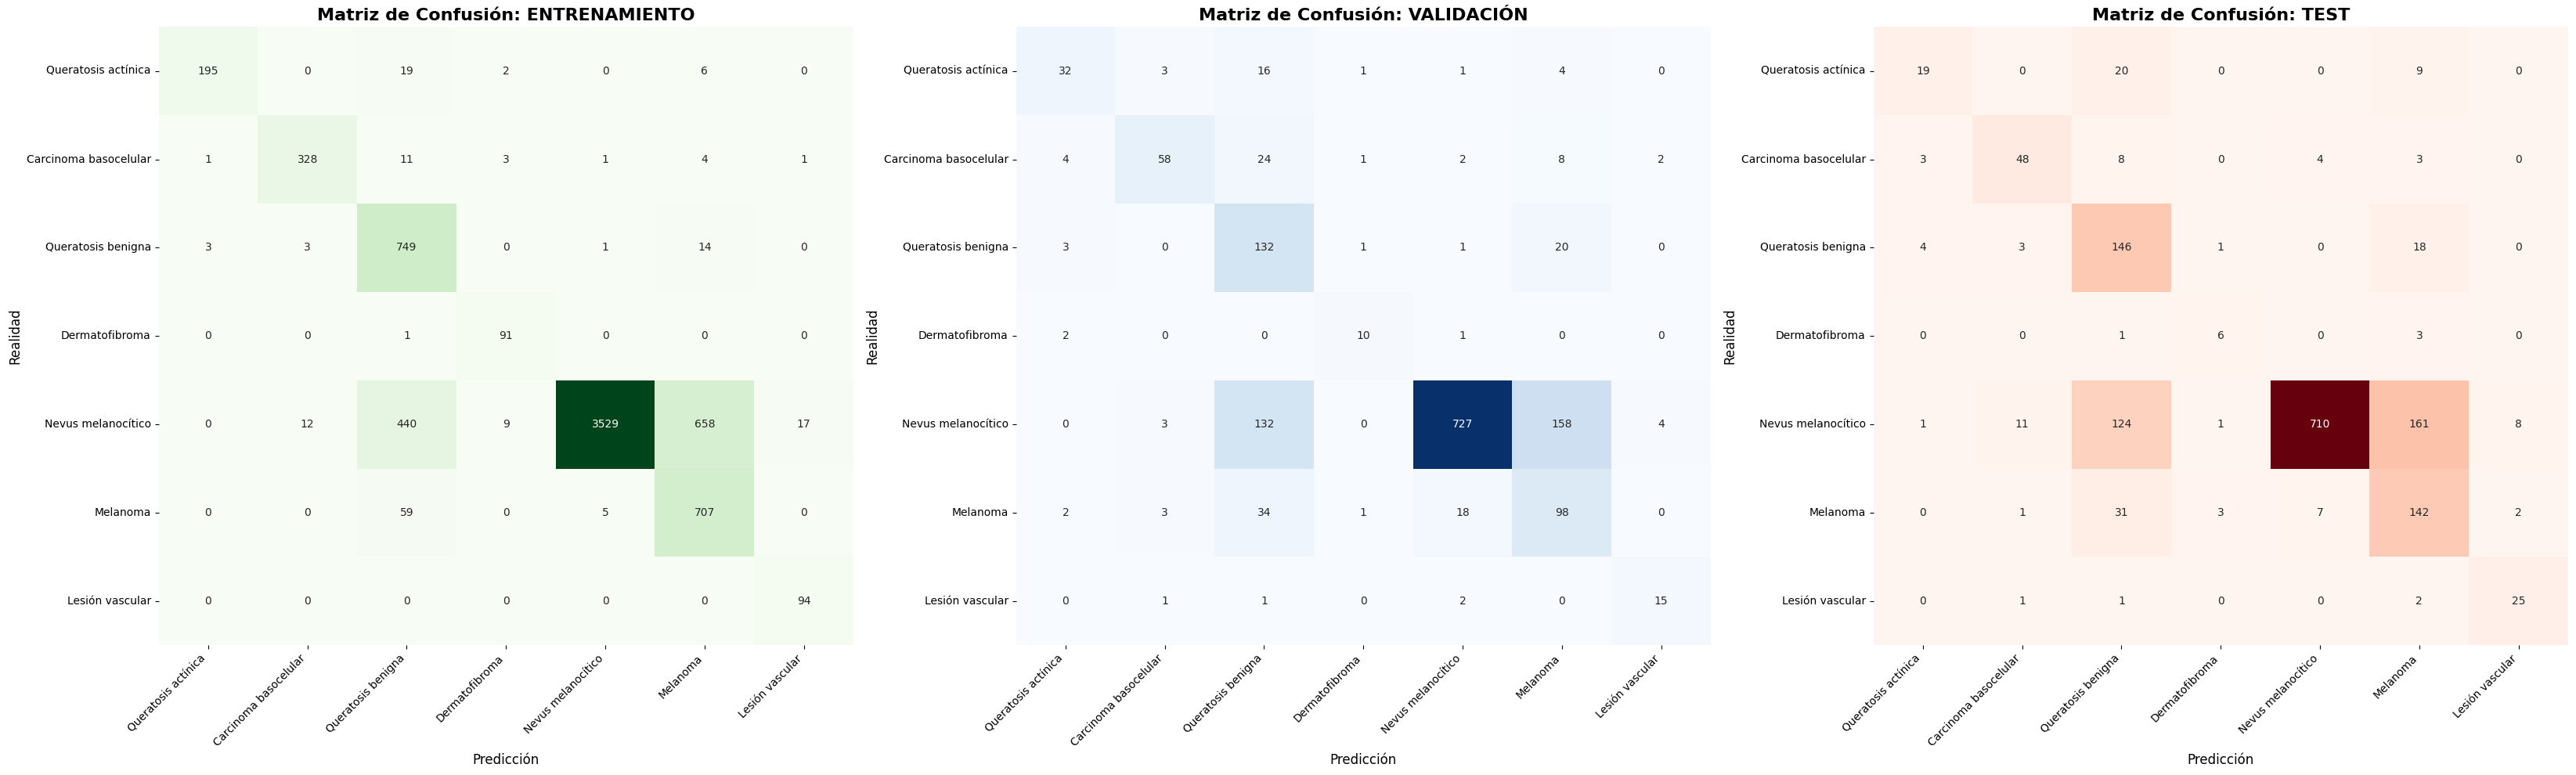

In [21]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculamos las matrices (la lógica sigue igual)
cm_train = confusion_matrix(y_true_train, y_pred_train)
cm_val = confusion_matrix(y_true_val, y_pred_val)
cm_test = confusion_matrix(y_true_test, y_pred_test)
# 2. Configuramos el gráfico
fig, ax = plt.subplots(1, 3, figsize=(33, 10)) # Aumentamos un poco el tamaño

# Matriz de Entrenamiento (Verde)
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Greens', ax=ax[0],
            xticklabels=class_names_es, yticklabels=class_names_es,
            cbar=False) # Quitamos la barra lateral para ganar espacio
ax[0].set_title('Matriz de Confusión: ENTRENAMIENTO', fontsize=16, fontweight='bold')
ax[0].set_xlabel('Predicción', fontsize=12)
ax[0].set_ylabel('Realidad', fontsize=12)

# Matriz de Validación (Azul)
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues', ax=ax[1],
            xticklabels=class_names_es, yticklabels=class_names_es,
            cbar=False)
ax[1].set_title('Matriz de Confusión: VALIDACIÓN', fontsize=16, fontweight='bold')
ax[1].set_xlabel('Predicción', fontsize=12)
ax[1].set_ylabel('Realidad', fontsize=12)

# Matriz de Test (Roja)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Reds', ax=ax[2],
            xticklabels=class_names_es, yticklabels=class_names_es,
            cbar=False)
ax[2].set_title('Matriz de Confusión: TEST', fontsize=16, fontweight='bold')
ax[2].set_xlabel('Predicción', fontsize=12)
ax[2].set_ylabel('Realidad', fontsize=12)

# --- AJUSTE CRÍTICO DE ETIQUETAS ---
# Rotamos las etiquetas de las X para que no se pisen
for a in ax:
    plt.sca(a)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

## 11: Inteligencia Artificial Explicable (XAI) - Grad-CAM
En esta sección visualizamos en qué regiones de la imagen se fija el modelo CoAtNet para clasificar las lesiones.


🚀 Generando tabla de: Aciertos del Modelo...


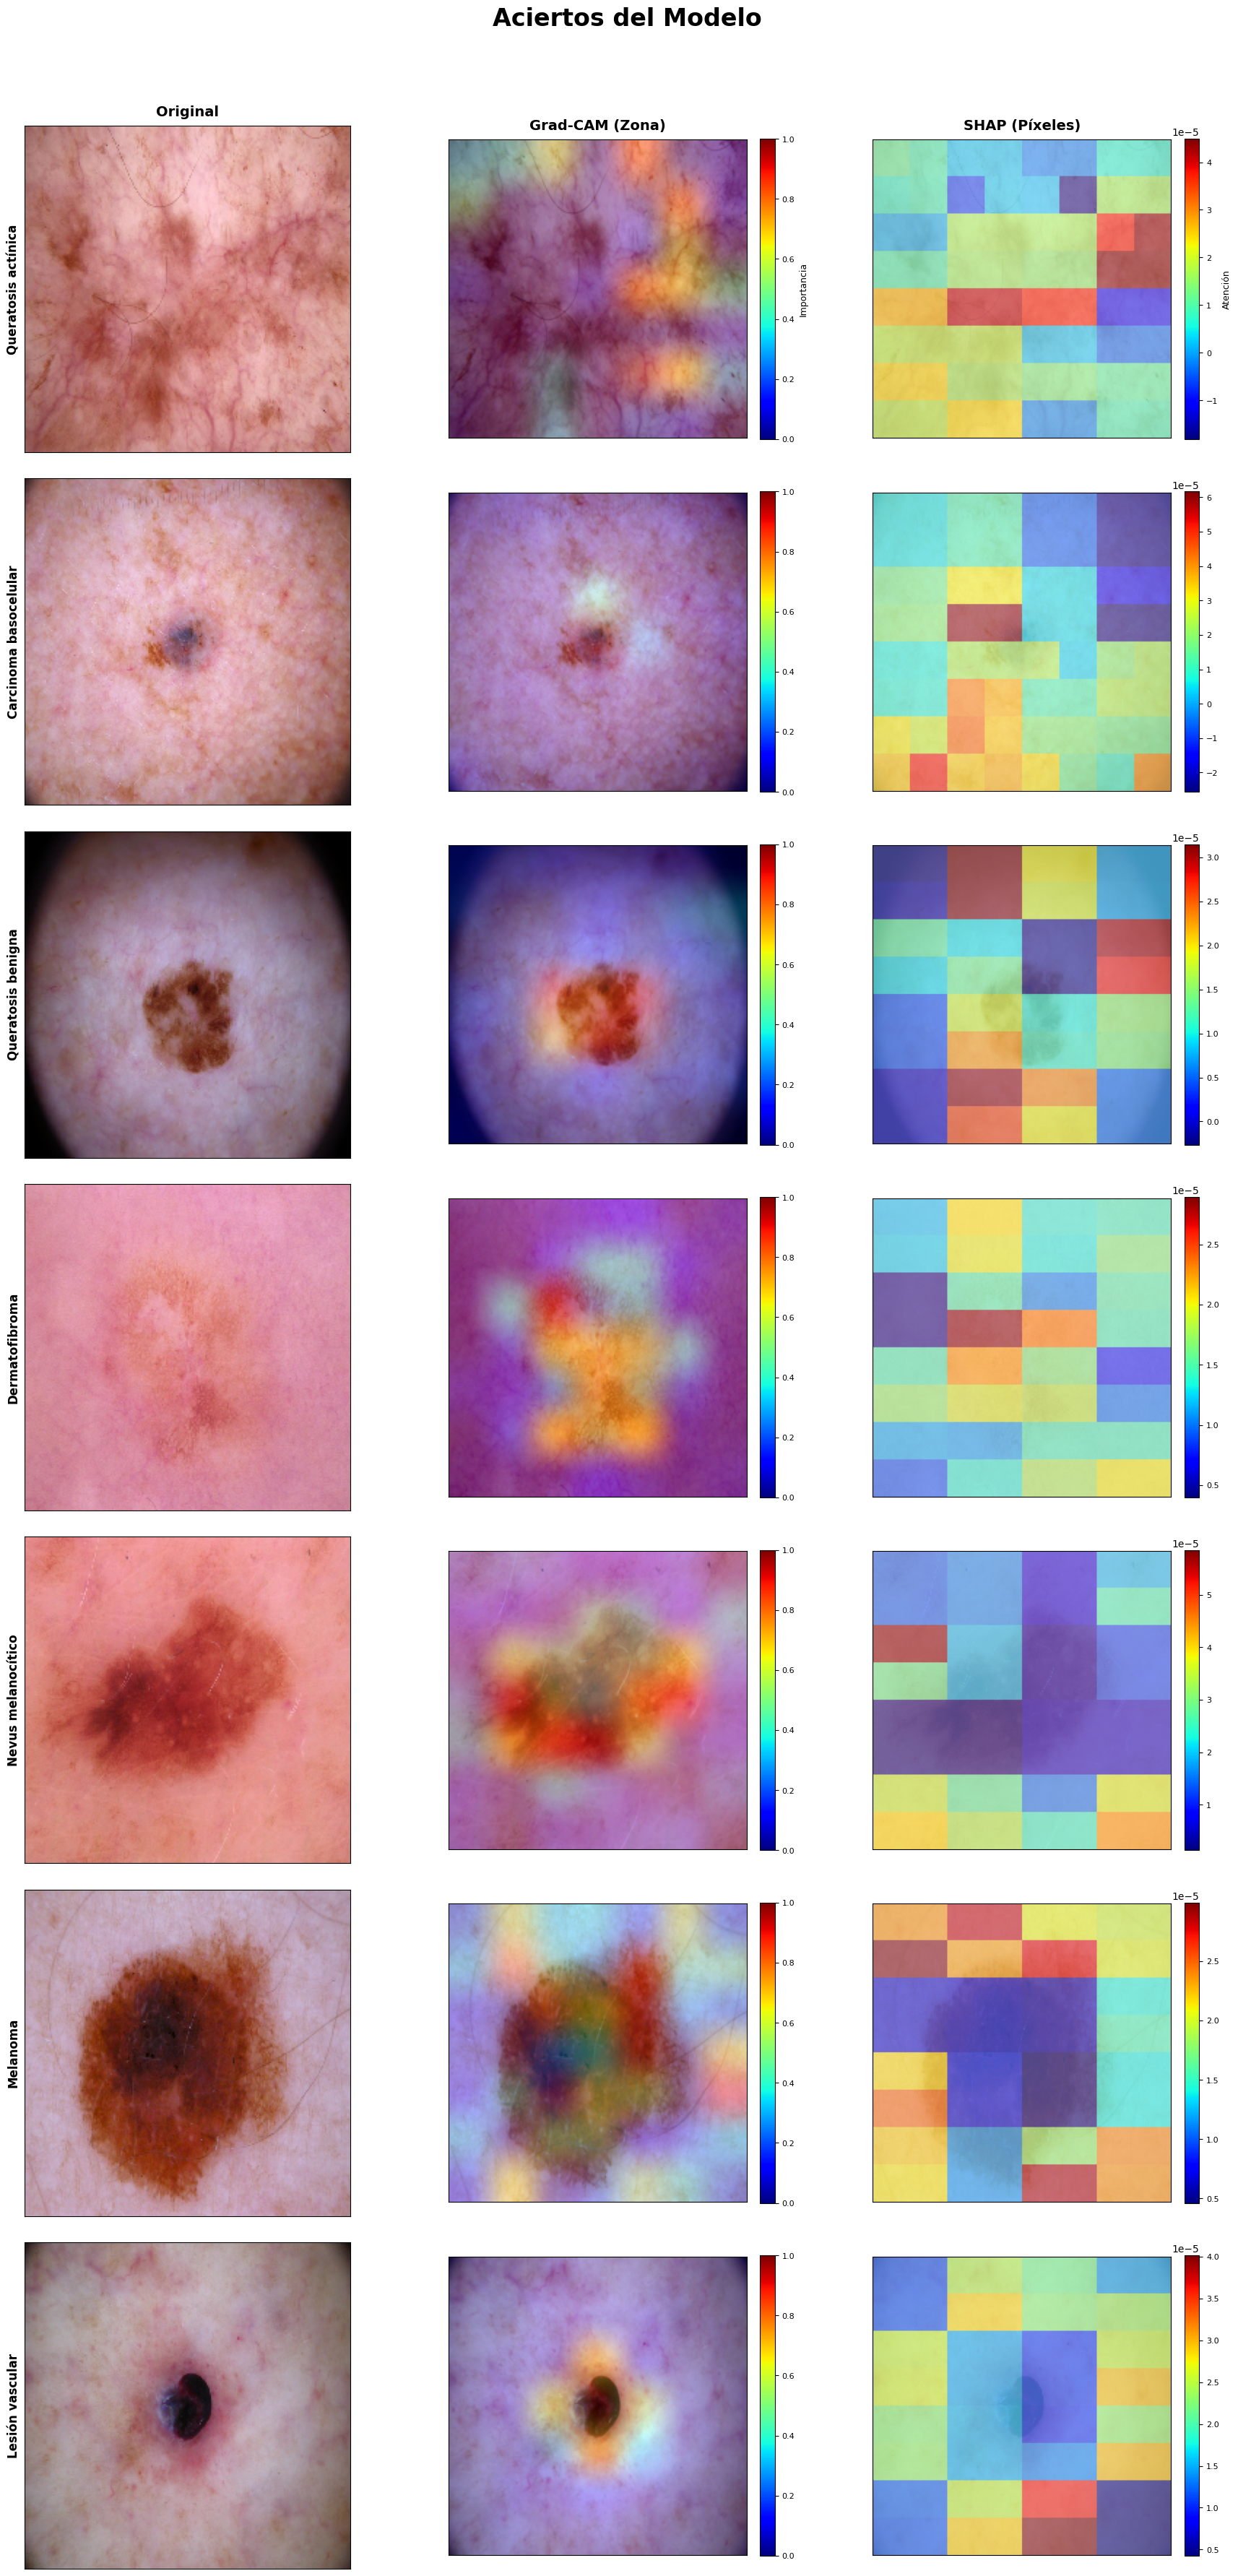

Error: You must call wandb.init() before wandb.log()

In [28]:
import matplotlib.cm as cm
import random
import contextlib
import shap
import numpy as np
import matplotlib.pyplot as plt
import os

# COMENTADO LIME
# import lime
# from lime import lime_image
# from skimage.segmentation import mark_boundaries, quickshift

# ==========================================
# 1. FUNCIONES CORE XAI
# ==========================================

def get_gradcam_heatmap(img_input, meta_input, model, last_conv_layer_name, pred_index):
    v_model = model.get_layer('coatnet0')
    inner_model = tf.keras.Model(
        inputs=v_model.inputs, 
        outputs=[v_model.get_layer(last_conv_layer_name).output, v_model.output]
    )
    pool_layer = [l for l in model.layers if isinstance(l, tf.keras.layers.GlobalAveragePooling2D)][0]
    concat_layer = [l for l in model.layers if isinstance(l, tf.keras.layers.Concatenate)][0]
    meta_branch = tf.keras.Model(inputs=model.input[1], outputs=concat_layer.input[1])
    
    top_input = tf.keras.Input(shape=concat_layer.output.shape[1:])
    x = top_input
    idx = model.layers.index(concat_layer)
    for layer in model.layers[idx+1:]:
        x = layer(x)
    top_model = tf.keras.Model(inputs=top_input, outputs=x)

    with tf.GradientTape() as tape:
        conv_output, backbone_out = inner_model(img_input)
        x_img = pool_layer(backbone_out)
        x_meta = meta_branch(meta_input)
        combined_features = concat_layer([x_img, x_meta])
        predictions = top_model(combined_features)
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = conv_output[0] @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-10)
    return heatmap.numpy()

def superimpose_heatmap(img_path, heatmap, alpha=0.4):
    img = tf.keras.utils.load_img(img_path)
    img_arr = tf.keras.utils.img_to_array(img)
    heatmap_arr = np.uint8(255 * heatmap)
    jet = plt.get_cmap("jet")(np.arange(256))[:, :3]
    jet_heatmap = tf.keras.utils.array_to_img(jet[heatmap_arr]).resize((img_arr.shape[1], img_arr.shape[0]))
    jet_heatmap = tf.keras.utils.img_to_array(jet_heatmap)
    return tf.keras.utils.array_to_img(jet_heatmap * alpha + img_arr)

# ==========================================
# 2. FUNCIÓN DE BÚSQUEDA INTELIGENTE
# ==========================================

def buscar_ejemplo(class_idx, test_df, mode='correct'):
    """ Busca en el set de test una imagen aleatoria que el modelo haya acertado o fallado """
    df_filtrado = test_df[test_df['label'] == class_idx].sample(frac=1) 
    
    for _, row in df_filtrado.iterrows():
        img_path = row['path']
        current_meta = np.array([row['meta']], dtype=np.float32)
        
        # Preparar imagen
        img_raw = tf.keras.utils.load_img(img_path, target_size=(224, 224))
        img_array = tf.keras.utils.img_to_array(img_raw)
        img_input = np.expand_dims(img_array, axis=0) / 255.0
        
        # Predecir
        pred = final_model.predict([img_input, current_meta], verbose=0)
        pred_idx = np.argmax(pred[0])
        
        # Comprobar condición
        if mode == 'correct' and pred_idx == class_idx:
            return img_path, img_input, img_raw, current_meta, pred_idx
        elif mode == 'incorrect' and pred_idx != class_idx:
            return img_path, img_input, img_raw, current_meta, pred_idx
            
    return None

# ==========================================
# 3. GENERACIÓN DE TABLAS
# ==========================================

sub_model = final_model.get_layer('coatnet0')
last_conv_name = [l.name for l in sub_model.layers if 'conv' in l.name.lower()][-1]

# COMENTADO LIME
# explainer_lime = lime_image.LimeImageExplainer()

# Eliminamos LIME de los títulos
col_titles = ['Original', 'Grad-CAM (Zona)', 'SHAP (Píxeles)']

modos = ['correct', 'incorrect']
titulos_tabla = ["Aciertos del Modelo", "Fallos del Modelo (Errores de Predicción)"]

for mode, titulo in zip(modos, titulos_tabla):
    print(f"\n🚀 Generando tabla de: {titulo}...")
    
    n_clases = len(class_names)
    
    # Reducimos ncols a 3 y ajustamos un poco el ancho del figsize (de 22 a 17)
    fig, axes = plt.subplots(nrows=n_clases, ncols=3, figsize=(17, 5 * n_clases))
    fig.suptitle(titulo, fontsize=24, fontweight='bold', y=1.02)
    
    # Silenciamos la verbosidad de SHAP
    with open(os.devnull, 'w') as f, contextlib.redirect_stdout(f), contextlib.redirect_stderr(f):
        for i, nombre_clase in enumerate(class_names):
            
            resultado = buscar_ejemplo(i, test_df, mode=mode)
            
            if resultado is None:
                axes[i, 0].text(0.5, 0.5, "Sin ejemplos disponibles", ha='center', va='center')
                axes[i, 0].set_ylabel(class_names_es[i], fontsize=12, fontweight='bold')
                for j in range(1, 3): axes[i, j].axis('off') # Cambiado de 4 a 3
                continue
                
            img_path, img_input, img_raw, current_meta, pred_idx = resultado

            def hybrid_predict(batch):
                m_batch = np.repeat(current_meta, batch.shape[0], axis=0)
                return final_model.predict([batch, m_batch], verbose=0)

            # 1. Grad-CAM
            h_map = get_gradcam_heatmap(img_input, current_meta, final_model, last_conv_name, pred_idx)
            gcam_res = superimpose_heatmap(img_path, h_map).resize((224, 224))
            mappable1 = cm.ScalarMappable(cmap="jet")
            mappable1.set_array([np.min(h_map), np.max(h_map)])
            cbar1 = plt.colorbar(mappable1, ax=axes[i, 1], fraction=0.046, pad=0.04)
            cbar1.ax.tick_params(labelsize=8)
            if i == 0: cbar1.set_label('Importancia', fontsize=9)
            
            # COMENTADO LIME
            # exp = explainer_lime.explain_instance(...)
            # temp, mask = exp.get_image_and_mask(...)
            
            # 2. SHAP (Antes era el paso 3)
            masker = shap.maskers.Image("blur(16,16)", shape=(224, 224, 3))
            expl_shap = shap.Explainer(hybrid_predict, masker, output_names=class_names_es)
            sv = expl_shap(img_input, max_evals=200, batch_size=50)
            shap_map = sv.values[0, :, :, :, pred_idx].sum(axis=-1)
            
            mappable3 = cm.ScalarMappable(cmap="jet")
            mappable3.set_array([np.min(shap_map), np.max(shap_map)])
            # Actualizamos ax=axes[i, 3] a ax=axes[i, 2]
            cbar3 = plt.colorbar(mappable3, ax=axes[i, 2], fraction=0.046, pad=0.04)
            cbar3.ax.tick_params(labelsize=8)
            if i == 0: cbar3.set_label('Atención', fontsize=9)

            # --- RENDERIZADO ---
            axes[i, 0].imshow(img_raw)
            
            if mode == 'correct':
                etiqueta = class_names_es[i]
            else:
                etiqueta = f"Real: {class_names_es[i]}\nPredijo: {class_names_es[pred_idx]}"
                
            axes[i, 0].set_ylabel(etiqueta, fontsize=12, fontweight='bold', color='red' if mode=='incorrect' else 'black')
            
            axes[i, 1].imshow(gcam_res)
            
            # COMENTADO LIME
            # axes[i, 2].imshow(mark_boundaries(temp, mask))
            
            # Actualizamos los índices de SHAP de 3 a 2
            axes[i, 2].imshow(img_raw, alpha=0.5)
            axes[i, 2].imshow(
                shap_map,
                cmap='jet',   
                alpha=0.5,
                vmin=np.min(shap_map),
                vmax=np.max(shap_map)
            )

            # Cambiamos el rango de 4 a 3 para limpiar los ejes
            for j in range(3):
                axes[i, j].set_xticks([]); axes[i, j].set_yticks([])
                if i == 0: axes[i, j].set_title(col_titles[j], fontweight='bold', fontsize=14, pad=10)

    plt.tight_layout()
    plt.subplots_adjust(wspace=0.3)
    plt.show()
    
    # Subir la tabla a W&B
    wandb.log({f"Tablas XAI / {titulo}": wandb.Image(fig)})

# FIN DEL BUCLE
wandb.finish()